## Load Data & Setup

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# Load data
df = pd.read_csv("./model_ready_data.csv")

target = "Delivery_Time_min"
numeric_features = ["Delivery_person_Age", "Delivery_person_Ratings", "Vehicle_condition",
                    "multiple_deliveries", "Distance_km", "Order_Hour", "Is_Weekend"]
categorical_features = ["Weatherconditions", "Road_traffic_density", "Type_of_order",
                        "Type_of_vehicle", "Festival", "City"]

X = df[numeric_features + categorical_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Preprocessor

In [ ]:
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', StandardScaler(), numeric_features)
])

## Hyperparameter Tuning (RandomizedSearchCV)

In [ ]:
# Define the Model
rf = RandomForestRegressor(random_state=42,n_jobs=-1)
# Full Pipeline
pipe = Pipeline([
    ('preprocessor',preprocessor),
    ('model',rf)
])

# Hyperparameter

param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [10, 15, 20, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

# Randomize
search = RandomizedSearchCV(
    pipe,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring='neg_mean_squared_error',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("Best Parameters:", search.best_params_)
print("Best Score:", -search.best_score_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_depth': 15}
Best Score: 16.05654869717571


## HyperParameter Tuning (GridSearchCv)

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV

# Define the Random Forest model
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# Full pipeline
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', rf)
])

# Hyperparameter grid
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [10, 15, 20, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

# Grid Search
search = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Run Grid Search
search.fit(X_train, y_train)

print("Best Parameters:", search.best_params_)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best Parameters: {'model__max_depth': 15, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 300}


## Train model with Output :
Best Parameters: {'model__max_depth': 15, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 300}



In [ ]:
# Train final model with best parameters from GridSearchCV
best_rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        min_samples_leaf=1,
        min_samples_split=10,
        random_state=42,
        n_jobs=-1
    ))
])

# Train the model
best_rf_pipeline.fit(X_train, y_train)

# Predictions
y_train_pred = best_rf_pipeline.predict(X_train)
y_test_pred = best_rf_pipeline.predict(X_test)

# Evaluation function
def evaluate_model(y_true, y_pred, dataset_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"\n{dataset_name} Performance:")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")
    return mae, rmse, r2

print("=== Final Random Forest Model (Optimized) ===")
print({
    "n_estimators": 300,
    "max_depth": 15,
    "min_samples_leaf": 1,
    "min_samples_split": 10
})

# Evaluate on both sets
train_mae, train_rmse, train_r2 = evaluate_model(y_train, y_train_pred, "Training")
test_mae, test_rmse, test_r2 = evaluate_model(y_test, y_test_pred, "Test")

# Overfitting check
print("\n=== Overfitting Check ===")
print(f"RMSE Difference (Train vs Test): {abs(train_rmse - test_rmse):.2f}")


if (train_rmse - test_rmse) < 0.5:
    print(" Model generalizes well (low overfitting risk)")
else:
    print(" Possible overfitting detected")

=== Final Random Forest Model (Optimized) ===
{'n_estimators': 300, 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 10}

Training Performance:
MAE  : 2.44
RMSE : 3.09
R²   : 0.8921

Test Performance:
MAE  : 3.12
RMSE : 3.92
R²   : 0.8243

=== Overfitting Check ===
RMSE Difference (Train vs Test): 0.83
 Model generalizes well (low overfitting risk)


## cross-validation

- The model exhibits moderate overfitting, but not severe overfitting. Its validation and test performance are consistent, indicating good generalization to unseen data.
- **The Random Forest** model achieved an R² of 0.821 during 5-fold cross-validation and 0.824 on the independent test set. The close agreement between cross-validation and test performance indicates that the model generalizes well to unseen data. Although the higher training R² (0.896) compared with validation R² (0.821) indicates some degree of overfitting, the relatively stable validation and test performance suggests that the overfitting is not severe.



In [ ]:
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    best_rf_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring={
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2"
    },
    return_train_score=True,
    n_jobs=-1
)

print("CV Train RMSE:",
      -cv_results["train_RMSE"].mean())

print("CV Validation RMSE:",
      -cv_results["test_RMSE"].mean())

print("CV Train R²:",
      cv_results["train_R2"].mean())

print("CV Validation R²:",
      cv_results["test_R2"].mean())

CV Train RMSE: 3.0246234569282184
CV Validation RMSE: 3.9721971065895416
CV Train R²: 0.8963177408206494
CV Validation R²: 0.8211011810078495


## Adjusted R²

In [ ]:
def adjusted_r2(r2, n, p):
    """
    r2 : R2 score
    n  : number of observations
    p  : number of features used
    """
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

n_features = best_rf_pipeline.named_steps["preprocessor"].transform(X_test).shape[1]
n_obs = X_test.shape[0]

adj_r2_test = adjusted_r2(test_r2, n_obs, n_features)

print("=== Final Metrics (Test Set) ===")
print(f"MAE         : {test_mae:.2f} minutes")
print(f"RMSE        : {test_rmse:.2f} minutes")
print(f"R²          : {test_r2:.4f}")
print(f"Adjusted R² : {adj_r2_test:.4f}")
print(f"\nNumber of features after encoding: {n_features}")
print(f"Number of test observations      : {n_obs}")




=== Final Metrics (Test Set) ===
MAE         : 3.12 minutes
RMSE        : 3.92 minutes
R²          : 0.8243
Adjusted R² : 0.8237

Number of features after encoding: 30
Number of test observations      : 8375


## Compare the model's performance on the Training data and Test
We compared the model’s performance on the training data and on unseen data to assess overfitting. The model achieved an **R² of 0.896 on the training set**, compared with **0.821 during cross-validation** and **0.824 on the test set**. The difference between the training and unseen-data performance indicates **some degree of overfitting**; however, the close agreement between the validation and test results suggests that the model **generalizes well to unseen data**.


## Feature Importance

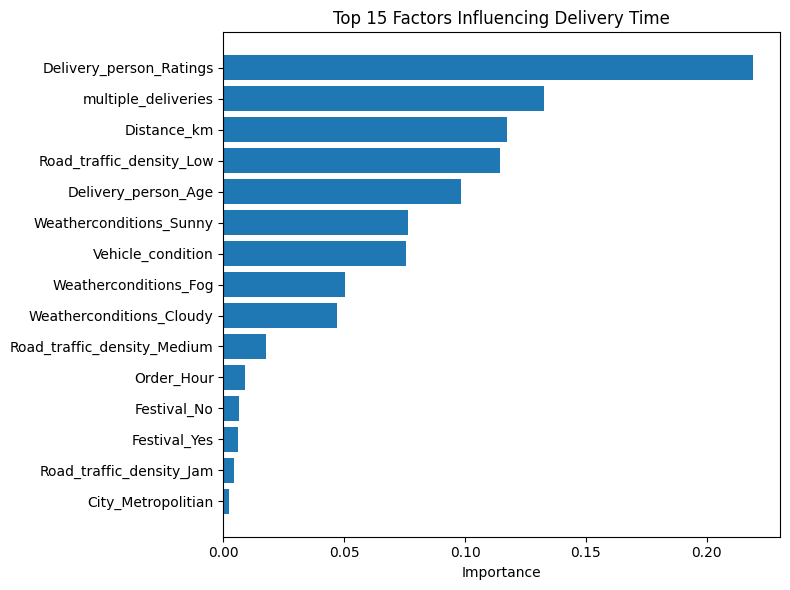

                    Feature  Importance
    Delivery_person_Ratings    0.219358
        multiple_deliveries    0.132631
                Distance_km    0.117323
   Road_traffic_density_Low    0.114532
        Delivery_person_Age    0.098346
    Weatherconditions_Sunny    0.076327
          Vehicle_condition    0.075387
      Weatherconditions_Fog    0.050250
   Weatherconditions_Cloudy    0.047093
Road_traffic_density_Medium    0.017789
                 Order_Hour    0.009034
                Festival_No    0.006432
               Festival_Yes    0.006001
   Road_traffic_density_Jam    0.004321
         City_Metropolitian    0.002443


In [ ]:
import matplotlib.pyplot as plt


# Get feature names after encoding
ohe = best_rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_names = ohe.get_feature_names_out(categorical_features).tolist()
feature_names = cat_names + numeric_features

importances = best_rf_pipeline.named_steps['model'].feature_importances_

imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(8, 6))
plt.barh(imp_df["Feature"][::-1], imp_df["Importance"][::-1])
plt.xlabel("Importance")
plt.title("Top 15 Factors Influencing Delivery Time")
plt.tight_layout()
plt.show()

print(imp_df.to_string(index=False))



## Save Pipeline

In [ ]:

import joblib
from google.colab import files

# The pipeline already contains the scaler + encoder so no separate scaler needed
joblib.dump(best_rf_pipeline, "delivery_model.pkl")

# Save the column structure needed by the app
model_config = {
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "metrics": {
        "MAE": round(test_mae, 2),
        "RMSE": round(test_rmse, 2),
        "R2": round(test_r2, 4),
        "Adjusted_R2": round(adj_r2_test, 4)
    },
    "categories": {col: sorted(df[col].dropna().unique().tolist())
                   for col in categorical_features}
}
joblib.dump(model_config, "model_config.pkl")

print("Saved: delivery_model.pkl + model_config.pkl")

# Download to local machine
files.download("delivery_model.pkl")
files.download("model_config.pkl")

Saved: delivery_model.pkl + model_config.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import sklearn
print(sklearn.__version__)

1.6.1
